# T1 Mapping with Synthetic Data

This notebook demonstrates T1 relaxometry using Digital Reference Objects (DROs) for validation.

## Learning Objectives

- Understand inversion recovery (IR) and variable TR (VTR) signal models
- Generate synthetic T1 data with known ground truth
- Compare general vs classical IR models
- Validate T1 fitting accuracy

## Background

### Inversion Recovery (General Model)

$$S = S_0 \left(1 - 2\alpha \exp\left(-\frac{TI}{T_1}\right) + \exp\left(-\frac{TR}{T_1}\right)\right)$$

### Inversion Recovery (Classical Model, TR >> T1)

$$S = S_0 \left(1 - 2\alpha \exp\left(-\frac{TI}{T_1}\right)\right)$$

### Variable TR (Saturation Recovery)

$$S = M \left(1 - \exp\left(-\frac{TR}{T_1}\right)\right)$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qmri.dro import relaxometry
from qmri.relaxometry import t1

## 1. Inversion Recovery T1 Mapping

Let's start with the inversion recovery method using the general model.

In [2]:
# Generate IR phantom with known T1
true_t1 = 1.2  # seconds (typical grey matter at 3T)
inversion_times = [0.05, 0.1, 0.2, 0.4, 0.8, 1.2, 2.0, 3.0]

phantom_ir = relaxometry.generate_t1_ir(
    t1=true_t1,
    inversion_times=inversion_times,
    s0=1000.0,
    repetition_time=5.0,
    inversion_efficiency=0.95,
    model="general",
    snr=100.0,
    seed=42,
)

print(f"Ground truth T1: {phantom_ir.ground_truth['t1'].value:.2f} s")
print(f"Inversion times: {phantom_ir.time_points}")
print(f"Signal: {phantom_ir.signal.round(1)}")

Ground truth T1: 1.20 s
Inversion times: [0.05 0.1  0.2  0.4  0.8  1.2  2.   3.  ]
Signal: [805.3 738.3 588.7 340.8  29.4 309.5 657.3 857.8]


In [3]:
# Fit T1
result_ir = t1.fit_ir(
    phantom_ir.signal,
    phantom_ir.time_points,
    repetition_times=phantom_ir.repetition_time,
    model="general",
)

print(f"Fitted T1: {float(result_ir.t1):.3f} s")
print(f"Fitted S0: {float(result_ir.s0):.1f}")
print(f"Fitted inversion efficiency: {float(result_ir.inversion_efficiency):.3f}")
print(f"Error: {100 * (float(result_ir.t1) - true_t1) / true_t1:.1f}%")

Fitted T1: 1.214 s
Fitted S0: 1003.5
Fitted inversion efficiency: 0.948
Error: 1.2%


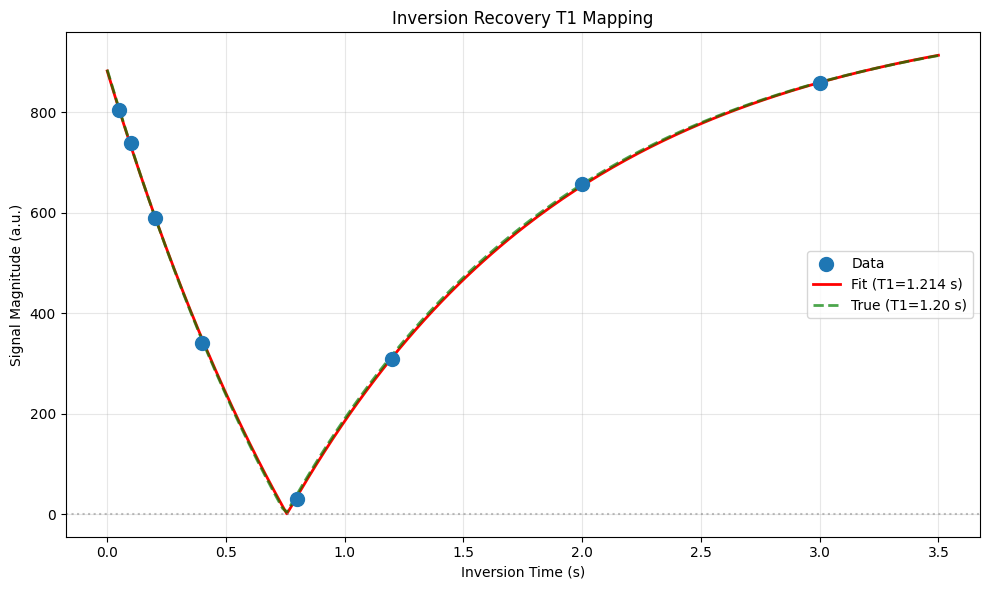

In [4]:
# Visualise IR curve
fig, ax = plt.subplots(figsize=(10, 6))

# Data points (magnitude)
ax.scatter(
    phantom_ir.time_points, np.abs(phantom_ir.signal), s=100, zorder=3, label="Data"
)

# Fitted curve
ti_fine = np.linspace(0, 3.5, 200)
s0_fit = float(result_ir.s0)
t1_fit = float(result_ir.t1)
alpha_fit = float(result_ir.inversion_efficiency)
s_fit = np.abs(
    t1.signal_ir(
        s0=s0_fit,
        t1=t1_fit,
        inversion_times=ti_fine,
        repetition_times=5.0,
        inversion_efficiency=alpha_fit,
    )
)
ax.plot(ti_fine, s_fit, "r-", linewidth=2, label=f"Fit (T1={t1_fit:.3f} s)")

# True curve
s_true = np.abs(
    t1.signal_ir(
        s0=1000,
        t1=true_t1,
        inversion_times=ti_fine,
        repetition_times=5.0,
        inversion_efficiency=0.95,
    )
)
ax.plot(
    ti_fine, s_true, "g--", linewidth=2, alpha=0.7, label=f"True (T1={true_t1:.2f} s)"
)

ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Inversion Time (s)")
ax.set_ylabel("Signal Magnitude (a.u.)")
ax.set_title("Inversion Recovery T1 Mapping")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. General vs Classical Model Comparison

The classical model assumes TR >> T1. Let's see what happens when this assumption is violated.

In [5]:
# Generate data with short TR (where classical assumption breaks down)
short_tr = 2.0  # TR = 2s, T1 = 1.2s → TR is NOT >> T1

phantom_short_tr = relaxometry.generate_t1_ir(
    t1=true_t1,
    inversion_times=inversion_times,
    repetition_time=short_tr,
    model="general",
    snr=100.0,
    seed=42,
)

# Fit with both models
result_general = t1.fit_ir(
    phantom_short_tr.signal,
    phantom_short_tr.time_points,
    repetition_times=short_tr,
    model="general",
)

result_classical = t1.fit_ir(
    phantom_short_tr.signal,
    phantom_short_tr.time_points,
    repetition_times=short_tr,
    model="classical",
)

print(f"True T1: {true_t1:.2f} s")
print(f"TR: {short_tr:.1f} s (TR/T1 = {short_tr / true_t1:.1f})")
print()
print(
    f"General model T1: {float(result_general.t1):.3f} s "
    f"(error: {100 * (float(result_general.t1) - true_t1) / true_t1:+.1f}%)"
)
print(
    f"Classical model T1: {float(result_classical.t1):.3f} s "
    f"(error: {100 * (float(result_classical.t1) - true_t1) / true_t1:+.1f}%)"
)

True T1: 1.20 s
TR: 2.0 s (TR/T1 = 1.7)

General model T1: 1.214 s (error: +1.2%)
Classical model T1: 1.214 s (error: +1.2%)


## 3. Variable TR (VTR) Method

In [6]:
# Generate VTR phantom
repetition_times = [0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]

phantom_vtr = relaxometry.generate_t1_vtr(
    t1=true_t1,
    repetition_times=repetition_times,
    m=1000.0,
    snr=100.0,
    seed=42,
)

print(f"Ground truth T1: {phantom_vtr.ground_truth['t1'].value:.2f} s")
print(f"TRs: {phantom_vtr.time_points}")
print(f"Signal: {phantom_vtr.signal.round(1)}")

Ground truth T1: 1.20 s
TRs: [0.3  0.5  0.75 1.   1.5  2.   3.   5.  ]
Signal: [223.1 334.3 469.5 571.3 701.3 803.  918.7 982.5]


In [7]:
# Fit VTR
result_vtr = t1.fit_vtr(phantom_vtr.signal, phantom_vtr.time_points)

print(f"Fitted T1: {float(result_vtr.t1):.3f} s")
print(f"Fitted M: {float(result_vtr.m):.1f}")
print(f"Error: {100 * (float(result_vtr.t1) - true_t1) / true_t1:.1f}%")

Fitted T1: 1.201 s
Fitted M: 996.9
Error: 0.1%


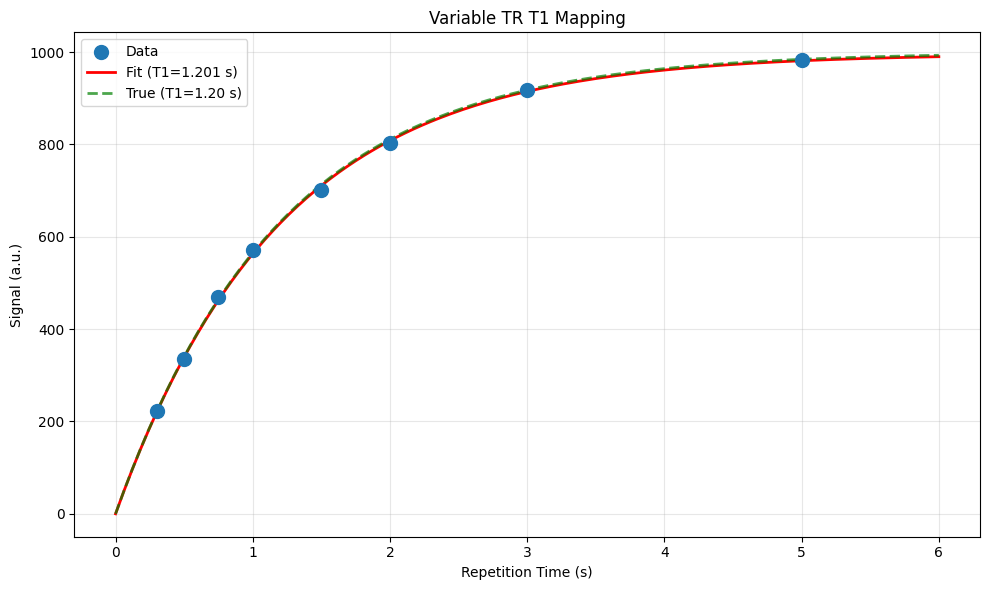

In [8]:
# Visualise VTR curve
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(phantom_vtr.time_points, phantom_vtr.signal, s=100, zorder=3, label="Data")

tr_fine = np.linspace(0, 6, 200)
t1_vtr_fit = float(result_vtr.t1)
m_fit = float(result_vtr.m)

s_vtr_fit = t1.signal_vtr(m=m_fit, t1=t1_vtr_fit, repetition_times=tr_fine)
ax.plot(tr_fine, s_vtr_fit, "r-", linewidth=2, label=f"Fit (T1={t1_vtr_fit:.3f} s)")

s_vtr_true = t1.signal_vtr(m=1000, t1=true_t1, repetition_times=tr_fine)
ax.plot(
    tr_fine,
    s_vtr_true,
    "g--",
    linewidth=2,
    alpha=0.7,
    label=f"True (T1={true_t1:.2f} s)",
)

ax.set_xlabel("Repetition Time (s)")
ax.set_ylabel("Signal (a.u.)")
ax.set_title("Variable TR T1 Mapping")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Multi-Voxel T1 Mapping

In [9]:
# Create a T1 map representing different tissues
t1_map = np.array(
    [
        [0.8, 0.9, 1.0, 1.1],
        [0.9, 1.0, 1.1, 1.2],
        [1.0, 1.1, 1.2, 1.3],
        [1.1, 1.2, 1.3, 1.4],
    ]
)

phantom_2d = relaxometry.generate_t1_ir(
    t1=t1_map,
    inversion_times=[0.1, 0.3, 0.5, 0.8, 1.2, 2.0],
    repetition_time=5.0,
    snr=50.0,
    seed=42,
)

# Fit
result_2d = t1.fit_ir(
    phantom_2d.signal,
    phantom_2d.time_points,
    repetition_times=5.0,
)

# Calculate error
error_map = 100 * (result_2d.t1 - t1_map) / t1_map

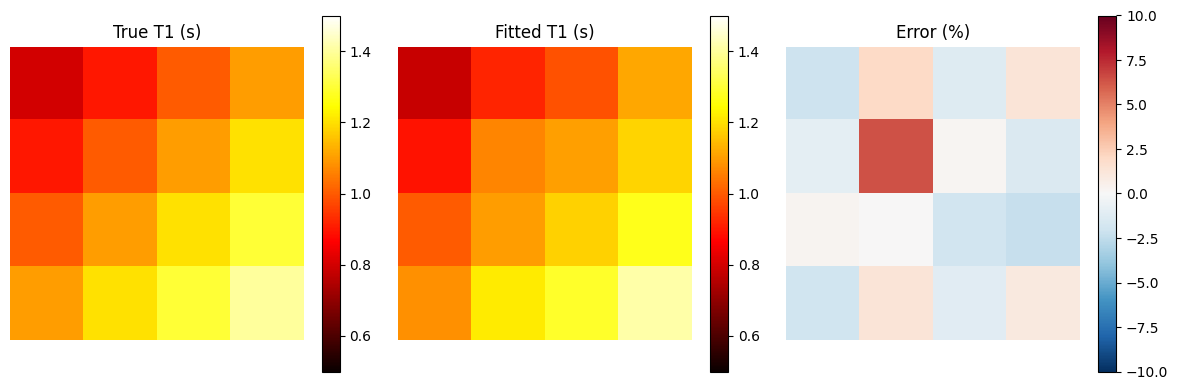

Mean absolute error: 1.6%


In [10]:
# Visualise
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(t1_map, cmap="hot", vmin=0.5, vmax=1.5)
axes[0].set_title("True T1 (s)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(result_2d.t1, cmap="hot", vmin=0.5, vmax=1.5)
axes[1].set_title("Fitted T1 (s)")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(error_map, cmap="RdBu_r", vmin=-10, vmax=10)
axes[2].set_title("Error (%)")
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Mean absolute error: {np.mean(np.abs(error_map)):.1f}%")

## Summary

Key takeaways:

1. **General vs Classical IR**: Use the general model when TR is not much larger than T1
2. **VTR method**: Simpler acquisition but requires more TRs for accuracy
3. **Inversion efficiency**: Real pulses are not perfect; model this for accuracy
4. **TI/TR selection**: Choose time points that sample the recovery curve well